In [96]:
# 导包
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pandas import Series
from sklearn.preprocessing import LabelEncoder
import torch
import sys
sys.path.append("..")
import SGLN
import lassonet
from sklearn.linear_model import Lasso
from groupyr import SGL
from grouplasso import GroupLassoRegressor

In [97]:
# 加载数据
mnist = loadmat('../data/Mnist/mnist-original.mat')

X = mnist['data'].T               #这个一定要转置一下，因为这里面的行列是反的！！！！！
print(X.shape)
X = X / 255.
X = X / 100.
y = mnist['label'].T.flatten()     #将数据展开
y= Series(y.astype(np.uint8))              #将格式变为uint8

data = []
target = []
j = 0
for i in range(10):
    filter = y == i
    data.append(X[filter])

(70000, 784)


In [98]:
# 构建数据
sample_num = 100
X_train = []
y_train = []


for i in range(0, 10):
     X_train += list(data[i])[0 : sample_num]

X_train = np.array(X_train).T
y_train = list(data[0])[100]

In [99]:
# 分组信息
Groups = []

for i in range(10):
     group = np.arange(start=i*sample_num, stop = (i+1)*sample_num, step=1)
     Groups.append(group)

# # 将特征组列表转换为数组格式
# group_array = np.zeros(1000, dtype=int)
# for i, group in enumerate(Groups):
#     group_array[group] = i

In [100]:
# SGLN
fig_name = "SGLN"
model = SGLN.LassoNetRegressor(
    hidden_dims=(100,),
    #n_iters=(3000, 500),   # 控制epochs
    lambda_start=0.2,
    path_multiplier=1.02,   # 控制Lambda_1变化趋势
    alpha=0.2,
    verbose=True,
    #patience=(100, 5)
)
path = model.path(X_train, y_train, Groups = Groups)

Initialized dense model
1000 epochs, val_objective 5.12e-07, val_loss 5.12e-07, regularization 0.00e+00, l2_regularization 3.21e-01
-------------------------- 1 --------------------------
Lambda_ = 0.20, selected 1000 features 
100 epochs, val_objective 7.30e-01, val_loss 5.25e-07, regularization 7.30e-01, l2_regularization 3.21e-01
-------------------------- 2 --------------------------
Lambda_ = 0.20, selected 1000 features 
100 epochs, val_objective 5.79e-01, val_loss 5.99e-07, regularization 5.79e-01, l2_regularization 3.21e-01
-------------------------- 3 --------------------------
Lambda_ = 0.21, selected 1000 features 
100 epochs, val_objective 4.53e-01, val_loss 7.84e-07, regularization 4.53e-01, l2_regularization 3.21e-01
-------------------------- 4 --------------------------
Lambda_ = 0.21, selected 1000 features 
100 epochs, val_objective 3.55e-01, val_loss 9.80e-07, regularization 3.55e-01, l2_regularization 3.21e-01
-------------------------- 5 --------------------------


In [101]:
# # LassoNet
# fig_name = "LassoNet"
# model = lassonet.LassoNetRegressor(
#     hidden_dims=(100,),
#     path_multiplier=1.005,   # 控制Lambda_1变化趋势
#     verbose=False,
#     patience=(100, 5)
# )
# path = model.path(X_train, y_train)
# index = -2
# weight = abs(np.array(path[index].state_dict['skip.weight'][0]))
# importances = weight / sum(weight)

In [102]:
# # Lasso
# fig_name = "Lasso"
# model = Lasso(alpha=0.001)
# model.fit(X_train, y_train)
# importances = abs(model.coef_) / np.sum(abs(model.coef_))

In [103]:
# # Group Lasso
# # fig_name = "GroupLasso"
# # model = GroupLassoRegressor(group_ids=group_array, random_state=42, verbose=False, alpha=0.0001)
# # model.fit(X_train, y_train)
# # importances = abs(model.coef_) / np.sum(abs(model.coef_))
# fig_name = "GroupLasso"
# model = SGL(
#     groups=Groups, l1_ratio=0, alpha=0.02431).fit(X_train, y_train)
# importances = abs(model.coef_) / np.sum(abs(model.coef_))

In [104]:
# # Sparse Group Lasso
# fig_name = "SGL"
# model = SGL(
#     groups=Groups, l1_ratio=0.5, alpha=0).fit(X_train, y_train)
# importances = abs(model.coef_) / np.sum(abs(model.coef_))

SGLN: 436


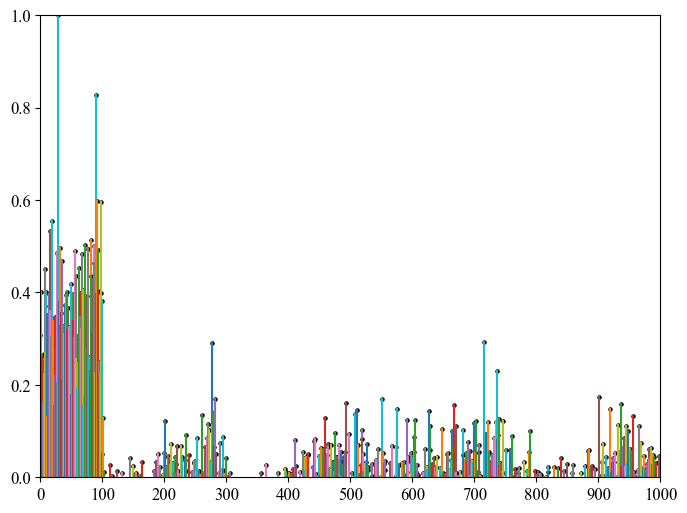

In [105]:
# 绘制测试数据的散点图
from matplotlib.pyplot import MultipleLocator
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

index = -2
weight = abs(np.array(path[index].state_dict['skip.weight'][0]))
importances = weight / sum(weight)
num = np.count_nonzero(importances)
print(str(fig_name) + ": " + str(num))


x=[]
y=[]


df = importances / importances.max()


# df = (importances - importances.min()) / (importances.max() - importances.min())
for i in range(len(df)):
    if df[i] != 0:
        yi = [df[i], -0.15]
        y.append(yi)
        xi = [i,i]
        x.append(xi)

config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}

rcParams.update(config)
plt.figure(dpi=100, figsize=(8, 6))

rng = np.random.RandomState(0)
colors = rng.rand(len(df))  # 随机产生50个用于颜色映射的数值
for i in range(len(x)):
    plt.scatter(x[i], y[i], color='black', s=5)
    plt.plot(x[i], y[i])


# 设置x轴刻度
x_major_locator = MultipleLocator(sample_num)
ax = plt.gca()
ax.xaxis.set_major_locator(x_major_locator)

plt.xlim(0, 1000)
plt.ylim(df.min(), df.max())

# plt.title("The feature importance of the picture '0'")
# plt.title(fig_name + ": Select " + str(num) + " features")
plt.savefig("figures/alpha/" + "alpha0.2" + ".pdf", bbox_inches='tight')
plt.show()

In [106]:
classify_weight = []
for i in range(0, 10):
     w = float(format(sum(importances[i*100: (i+1)*100]) / sum(importances), '.3f'))
     classify_weight.append(w)
print(classify_weight)

[0.695, 0.011, 0.056, 0.002, 0.041, 0.04, 0.045, 0.051, 0.009, 0.051]
